# ML / AI / DS — анализ рынка вакансий России 2026
### Exploratory Data Analysis

**Данные:** `data/cleaned.json` (после `2_wrangling.py`)  
**Записей:** 1535 вакансий с hh.ru

In [1]:
import json
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline

plt.rcParams.update({
    "figure.dpi":      130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family":     "DejaVu Sans",
    "axes.titlesize":  14,
    "axes.labelsize":  12,
})
PALETTE = ["#3266AD", "#5DCAA5", "#EF9F27", "#D4537E", "#7F77DD",
           "#B4B2A9", "#4CAF50", "#FF5722", "#009688", "#673AB7"]

# Загружаем уже очищенные данные
with open("data/cleaned.json", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df["salary_mid"] = pd.to_numeric(df["salary_mid"], errors="coerce")

# Красивые названия категорий
CAT_LABELS = {
    "llm":              "LLM / GenAI",
    "computer_vision":  "Computer Vision",
    "nlp":              "NLP",
    "mlops":            "MLOps",
    "research":         "ML Research",
    "data_science":     "Data Science",
    "ml_engineer":      "ML Engineer",
    "ai_engineer":      "AI Engineer",
    "data_engineer":    "Data Engineer",
    "general_ml":       "General ML",
}
df["category_label"] = df["category"].map(CAT_LABELS).fillna(df["category"])

# Все навыки плоским списком
all_skills = [s for skills in df["skills"] for s in skills]

print(f"Всего вакансий:    {len(df)}")
print(f"С описанием:       {df['has_desc'].sum()}")
print(f"С зарплатой:       {df['salary_mid'].notna().sum()}")
print(f"Уникальных навыков: {len(set(all_skills))}")
df[["title","level","category_label","city","skills"]].head(4)

Всего вакансий:    1535
С описанием:       1253
С зарплатой:       29
Уникальных навыков: 57


,title,level,category_label,city,skills
0,Machine Learning Engineer,senior,ML Engineer,Москва,"[Python, C++, PyTorch, OpenCV, ONNX, TensorRT,..."
1,ML Engineer,middle,Computer Vision,Москва,"[Python, SQL, Bash, PyTorch, scikit-learn, Ope..."
2,Senior AI Engineer / Senior Data Scientist (LL...,senior,LLM / GenAI,Санкт-Петербург,"[SQL, PyTorch, TensorFlow, GPT, LLM, HuggingFa..."
3,ML-инженер/Machine Learning Engineer,junior,MLOps,Москва,"[Python, SQL, Bash, MLflow, Airflow, Kubeflow,..."


## 1. Распределение по грейдам

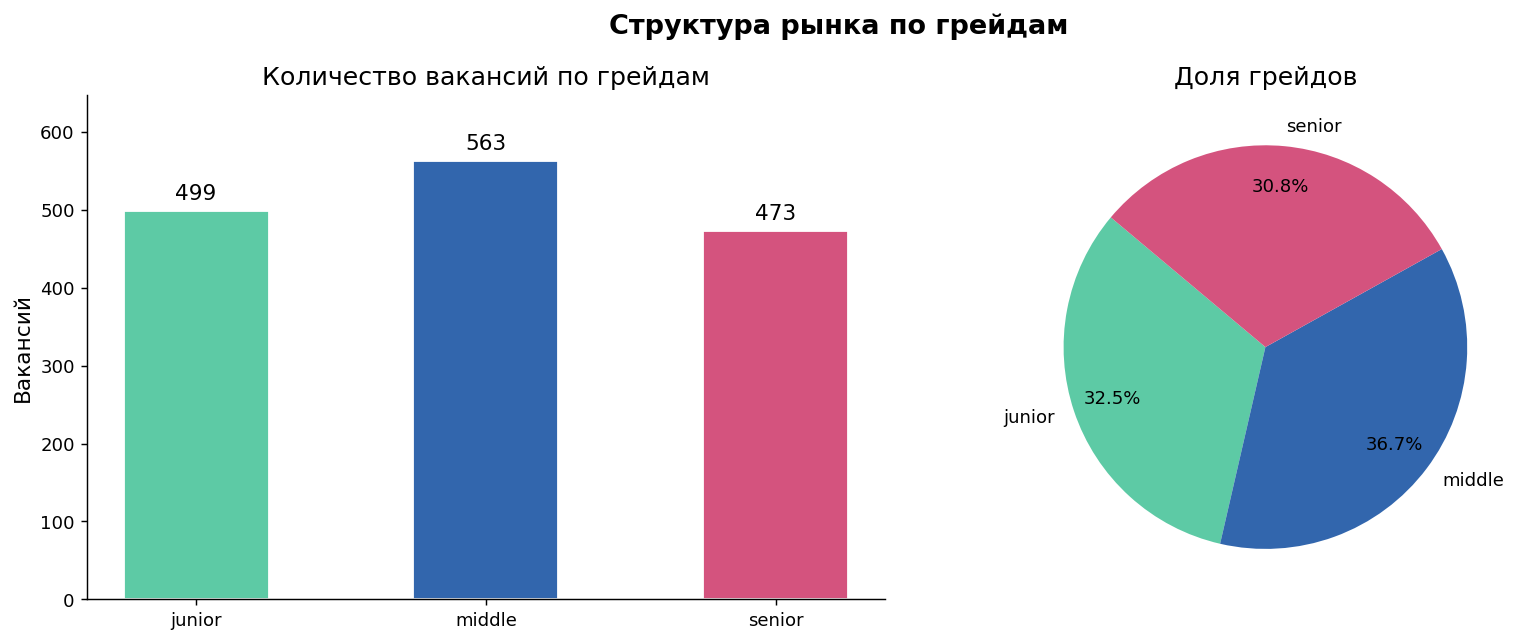

In [2]:
level_counts = df["level"].value_counts().reindex(["junior", "middle", "senior"])
level_colors = ["#5DCAA5", "#3266AD", "#D4537E"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar
bars = axes[0].bar(level_counts.index, level_counts.values,
                   color=level_colors, width=0.5, edgecolor="white")
axes[0].bar_label(bars, fmt="%d", padding=4, fontsize=12)
axes[0].set_title("Количество вакансий по грейдам")
axes[0].set_ylabel("Вакансий")
axes[0].set_ylim(0, level_counts.max() * 1.15)

# Pie
axes[1].pie(level_counts.values, labels=level_counts.index,
            colors=level_colors, autopct="%1.1f%%",
            startangle=140, pctdistance=0.8)
axes[1].set_title("Доля грейдов")

plt.suptitle("Структура рынка по грейдам", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Специализации

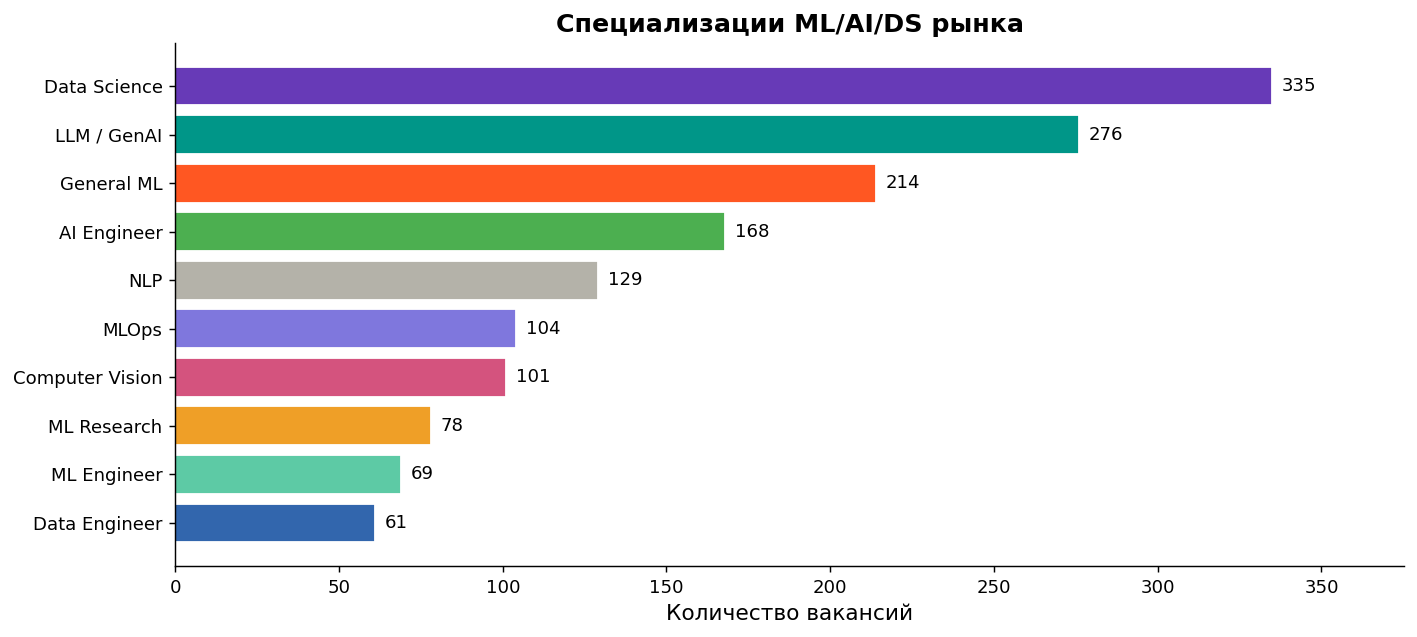

In [3]:
cat_counts = df["category_label"].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
               color=PALETTE[:len(cat_counts)], edgecolor="white")
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10)
ax.set_xlabel("Количество вакансий")
ax.set_title("Специализации ML/AI/DS рынка", fontweight="bold")
ax.set_xlim(0, cat_counts.max() * 1.12)
plt.tight_layout()
plt.show()

## 3. Топ-25 навыков

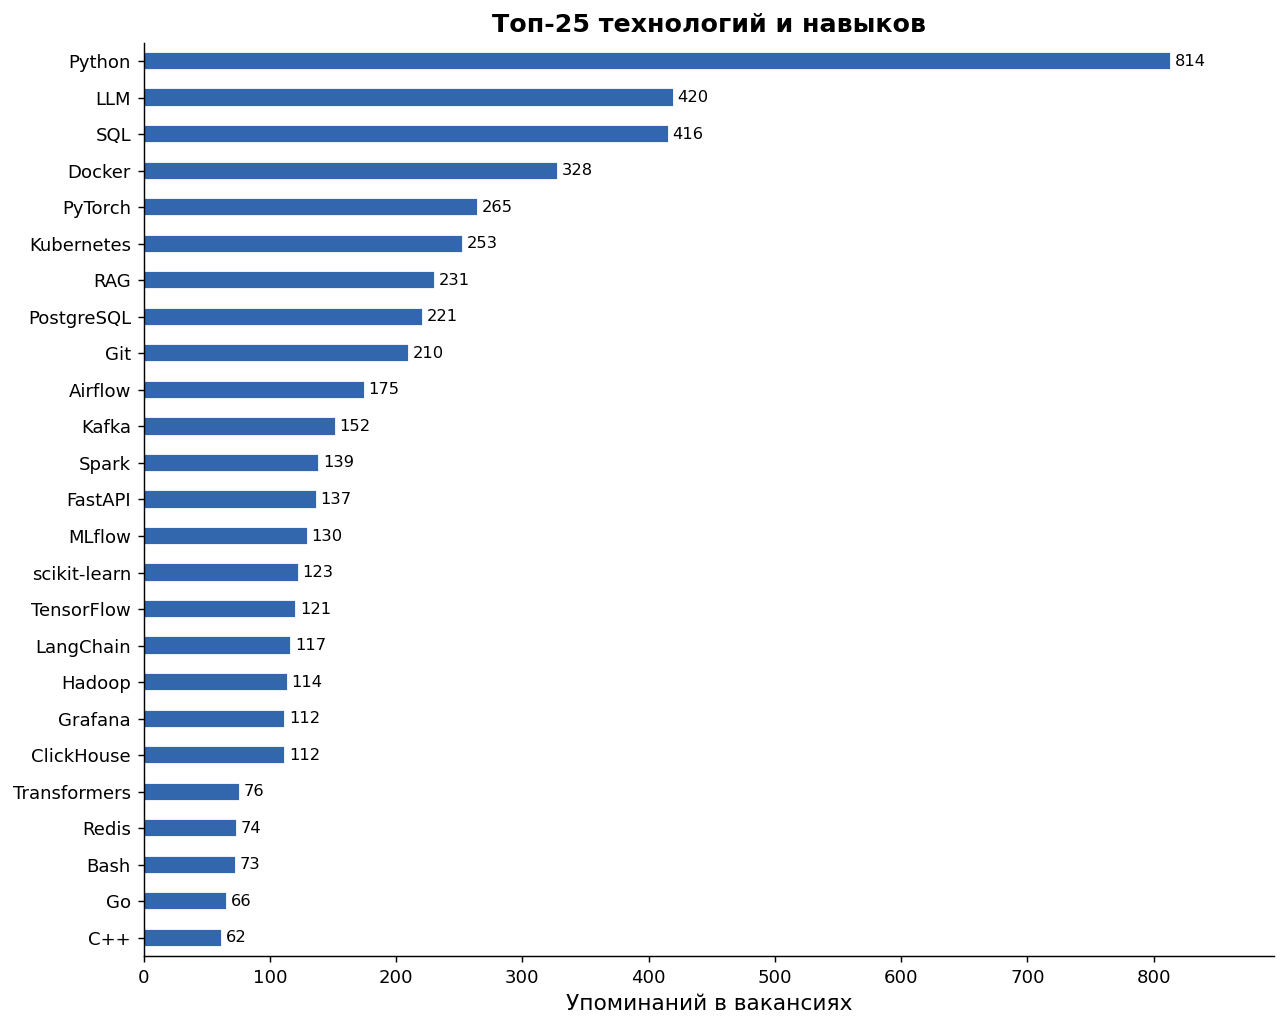

In [4]:
skill_counter = Counter(all_skills)
top25 = pd.Series(skill_counter).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
top25.sort_values().plot.barh(ax=ax, color="#3266AD", edgecolor="white")
for bar in ax.patches:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va="center", fontsize=9)
ax.set_title("Топ-25 технологий и навыков", fontweight="bold")
ax.set_xlabel("Упоминаний в вакансиях")
ax.set_xlim(0, top25.max() * 1.1)
plt.tight_layout()
plt.show()

## 4. Навыки по грейдам — что отличает junior / middle / senior

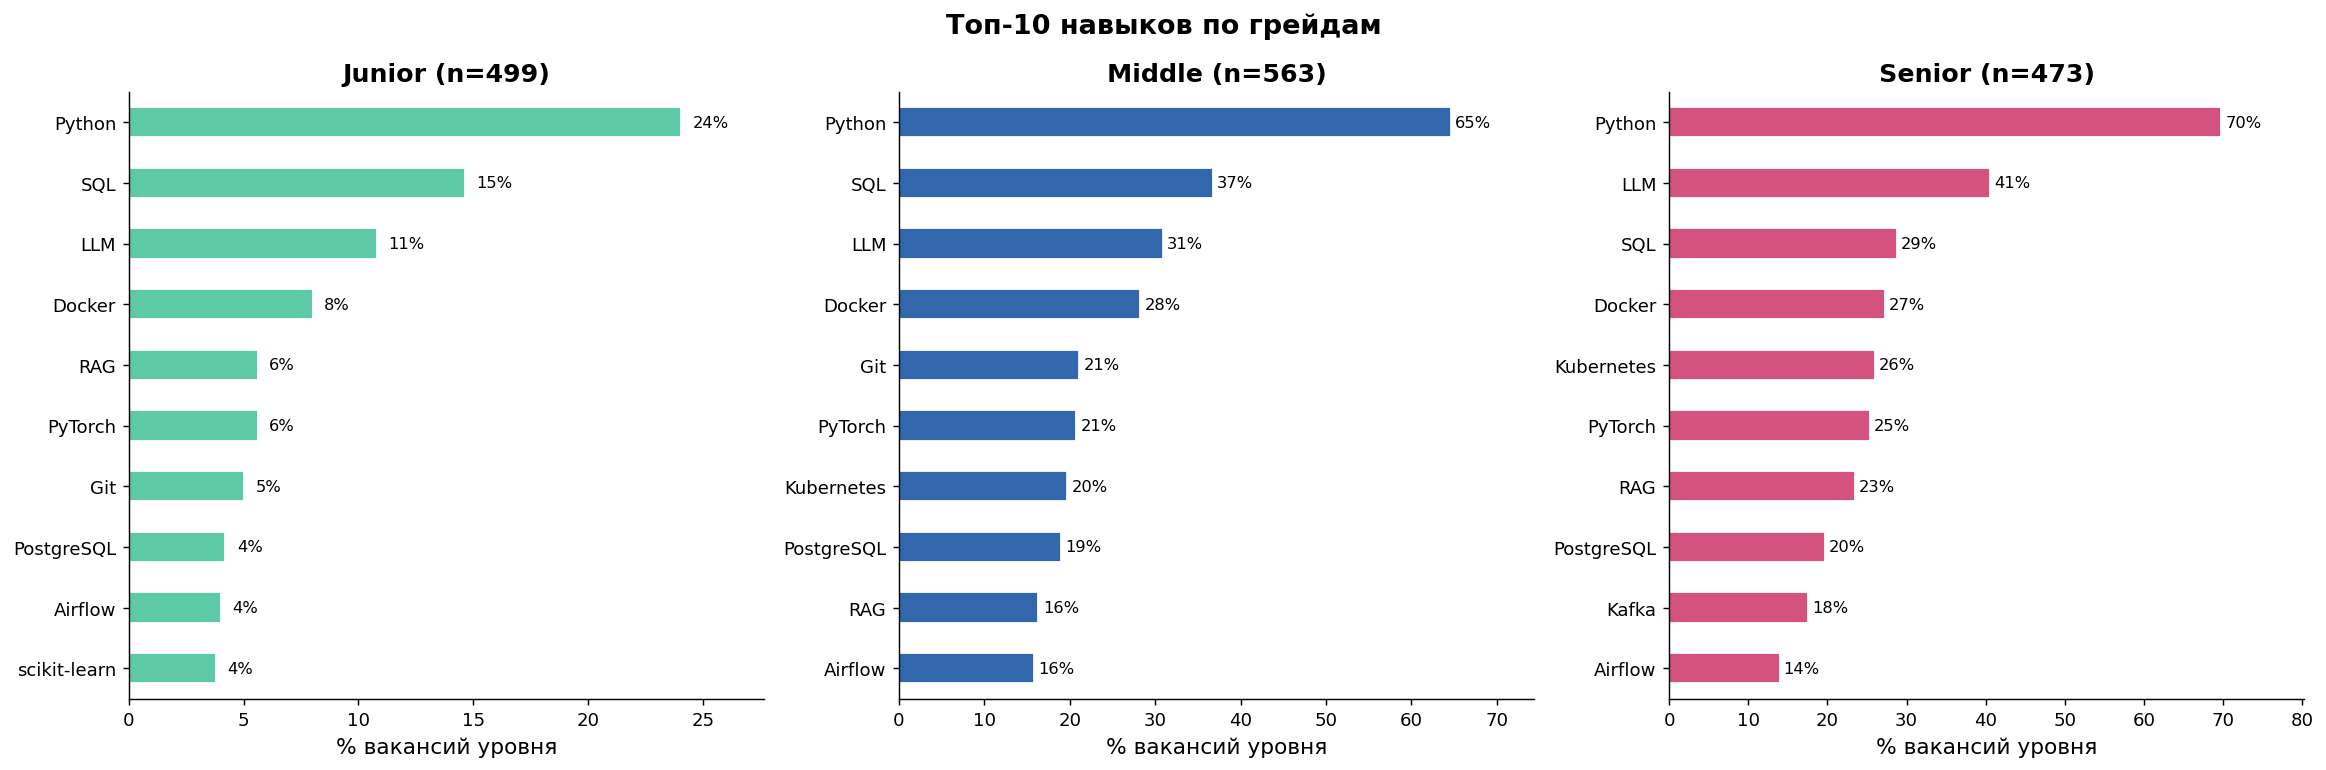

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_map = {"junior": "#5DCAA5", "middle": "#3266AD", "senior": "#D4537E"}

for ax, level in zip(axes, ["junior", "middle", "senior"]):
    sub = df[df["level"] == level]
    flat = [s for skills in sub["skills"] for s in skills]
    total = len(sub)
    top10 = pd.Series(Counter(flat)).sort_values(ascending=False).head(10)
    # Показываем % от вакансий уровня
    top10_pct = (top10 / total * 100).sort_values()
    top10_pct.plot.barh(ax=ax, color=colors_map[level], edgecolor="white")
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.0f}%", va="center", fontsize=9)
    ax.set_title(f"{level.capitalize()} (n={total})", fontweight="bold")
    ax.set_xlabel("% вакансий уровня")
    ax.set_xlim(0, top10_pct.max() * 1.15)

plt.suptitle("Топ-10 навыков по грейдам", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Тепловая карта навыков по грейдам

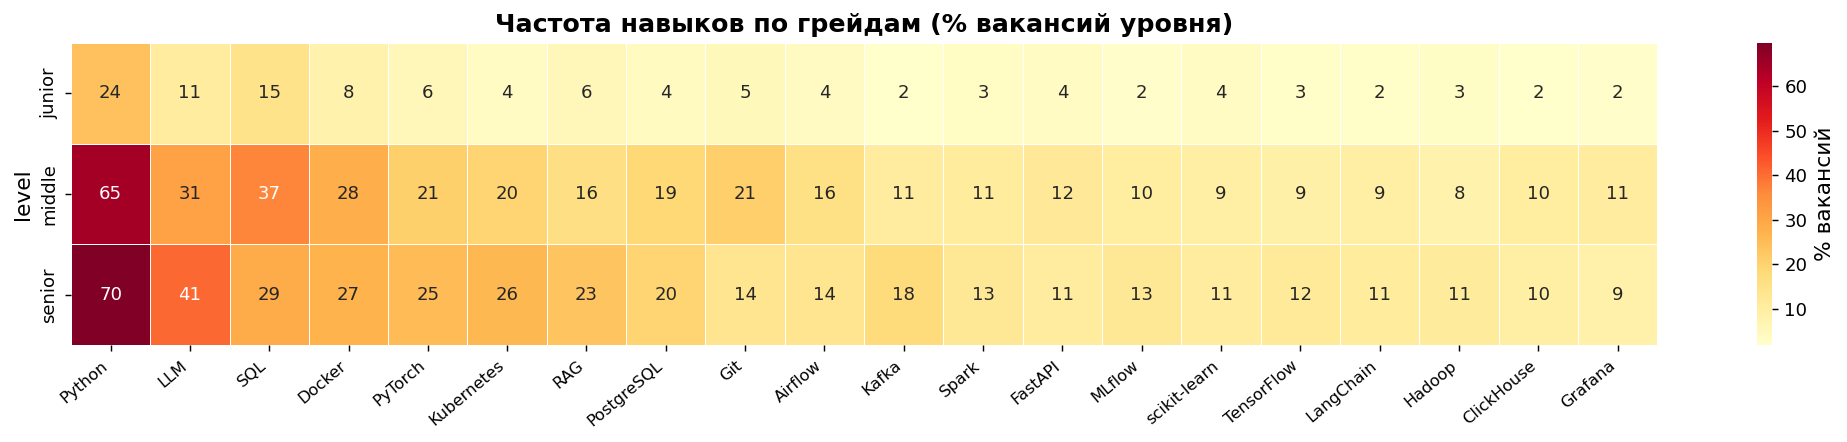

In [6]:
top20_skills = [s for s, _ in Counter(all_skills).most_common(20)]

heat_rows = []
for level in ["junior", "middle", "senior"]:
    sub = df[df["level"] == level]
    flat = [s for skills in sub["skills"] for s in skills]
    total = len(sub) or 1
    heat_rows.append(
        {skill: flat.count(skill) / total * 100 for skill in top20_skills} | {"level": level}
    )

heat_df = pd.DataFrame(heat_rows).set_index("level")[top20_skills]

fig, ax = plt.subplots(figsize=(16, 3.5))
sns.heatmap(heat_df, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "% вакансий"})
ax.set_title("Частота навыков по грейдам (% вакансий уровня)", fontweight="bold")
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Специализации × Грейды

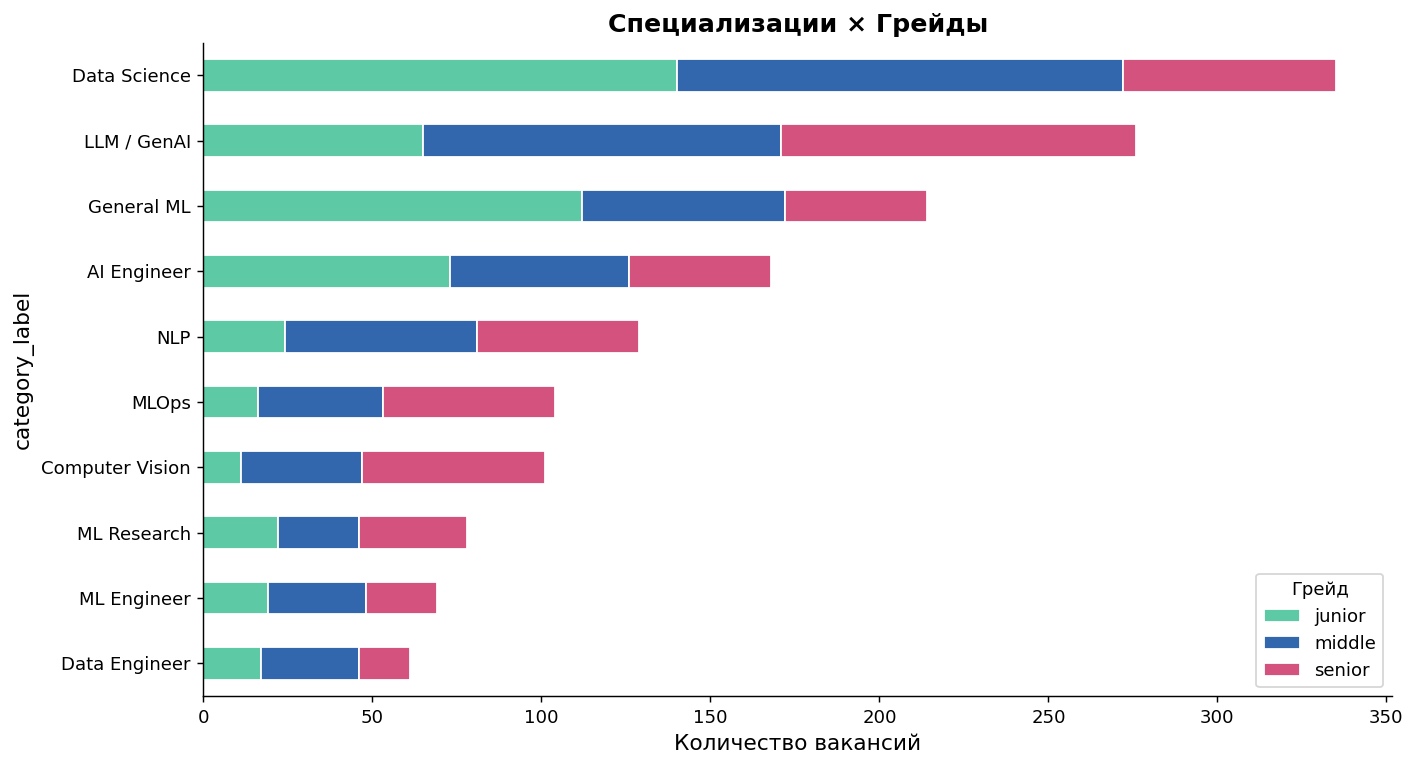

In [7]:
pivot = df.groupby(["category_label", "level"]).size().unstack(fill_value=0)
# Сортируем по суммарному кол-ву
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]
# Оставляем только junior/middle/senior
for col in ["junior", "middle", "senior"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["junior", "middle", "senior"]]

fig, ax = plt.subplots(figsize=(11, 6))
pivot.plot.barh(ax=ax, color=["#5DCAA5", "#3266AD", "#D4537E"],
                stacked=True, edgecolor="white")
ax.set_title("Специализации × Грейды", fontweight="bold")
ax.set_xlabel("Количество вакансий")
ax.legend(title="Грейд", loc="lower right")
plt.tight_layout()
plt.show()

## 7. География рынка

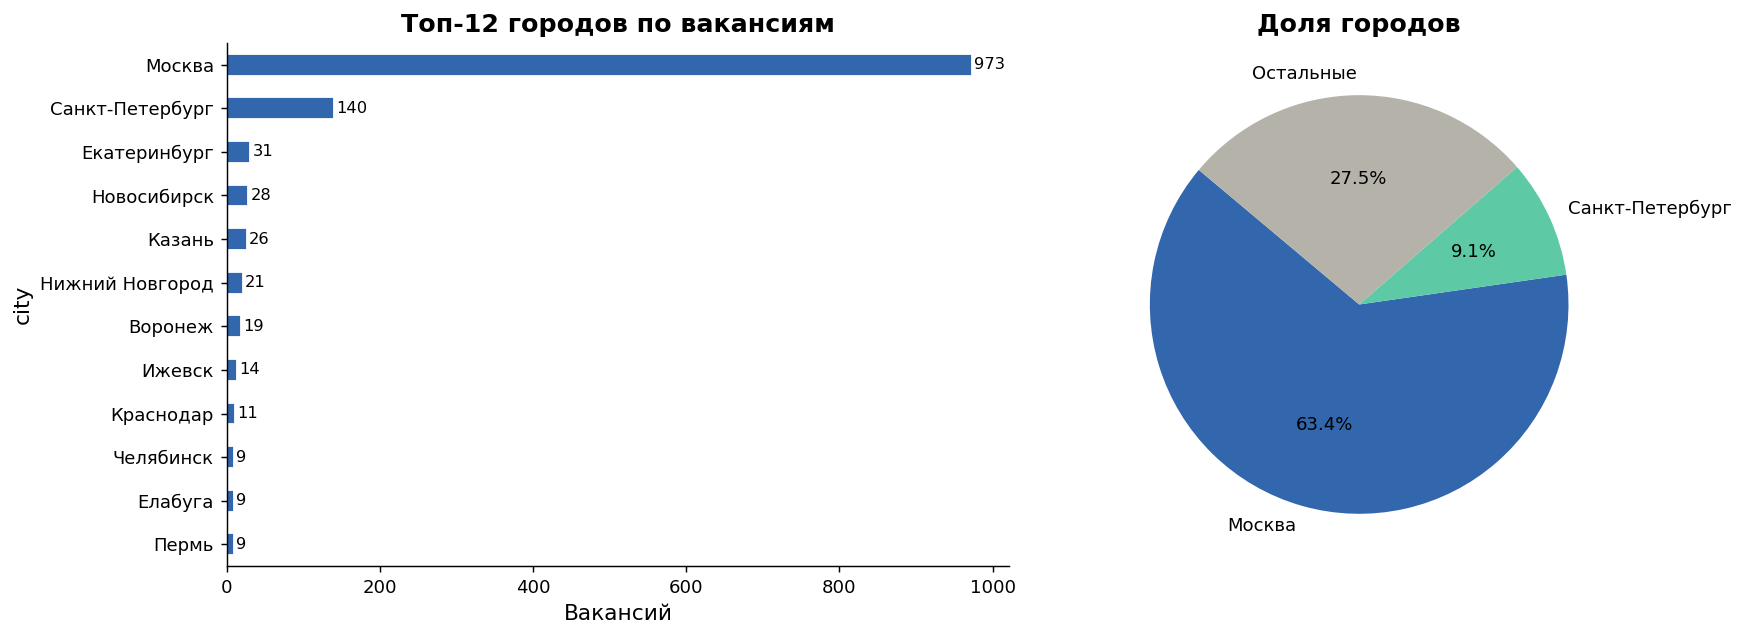

In [8]:
city_counts = df["city"].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

city_counts.sort_values().plot.barh(ax=axes[0], color="#3266AD", edgecolor="white")
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
                 str(int(bar.get_width())), va="center", fontsize=9)
axes[0].set_title("Топ-12 городов по вакансиям", fontweight="bold")
axes[0].set_xlabel("Вакансий")

# Москва vs остальные
msk = df[df["city"] == "Москва"].shape[0]
spb = df[df["city"] == "Санкт-Петербург"].shape[0]
other = len(df) - msk - spb
axes[1].pie([msk, spb, other],
            labels=["Москва", "Санкт-Петербург", "Остальные"],
            colors=["#3266AD", "#5DCAA5", "#B4B2A9"],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Доля городов", fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Co-occurrence навыков — что встречается вместе

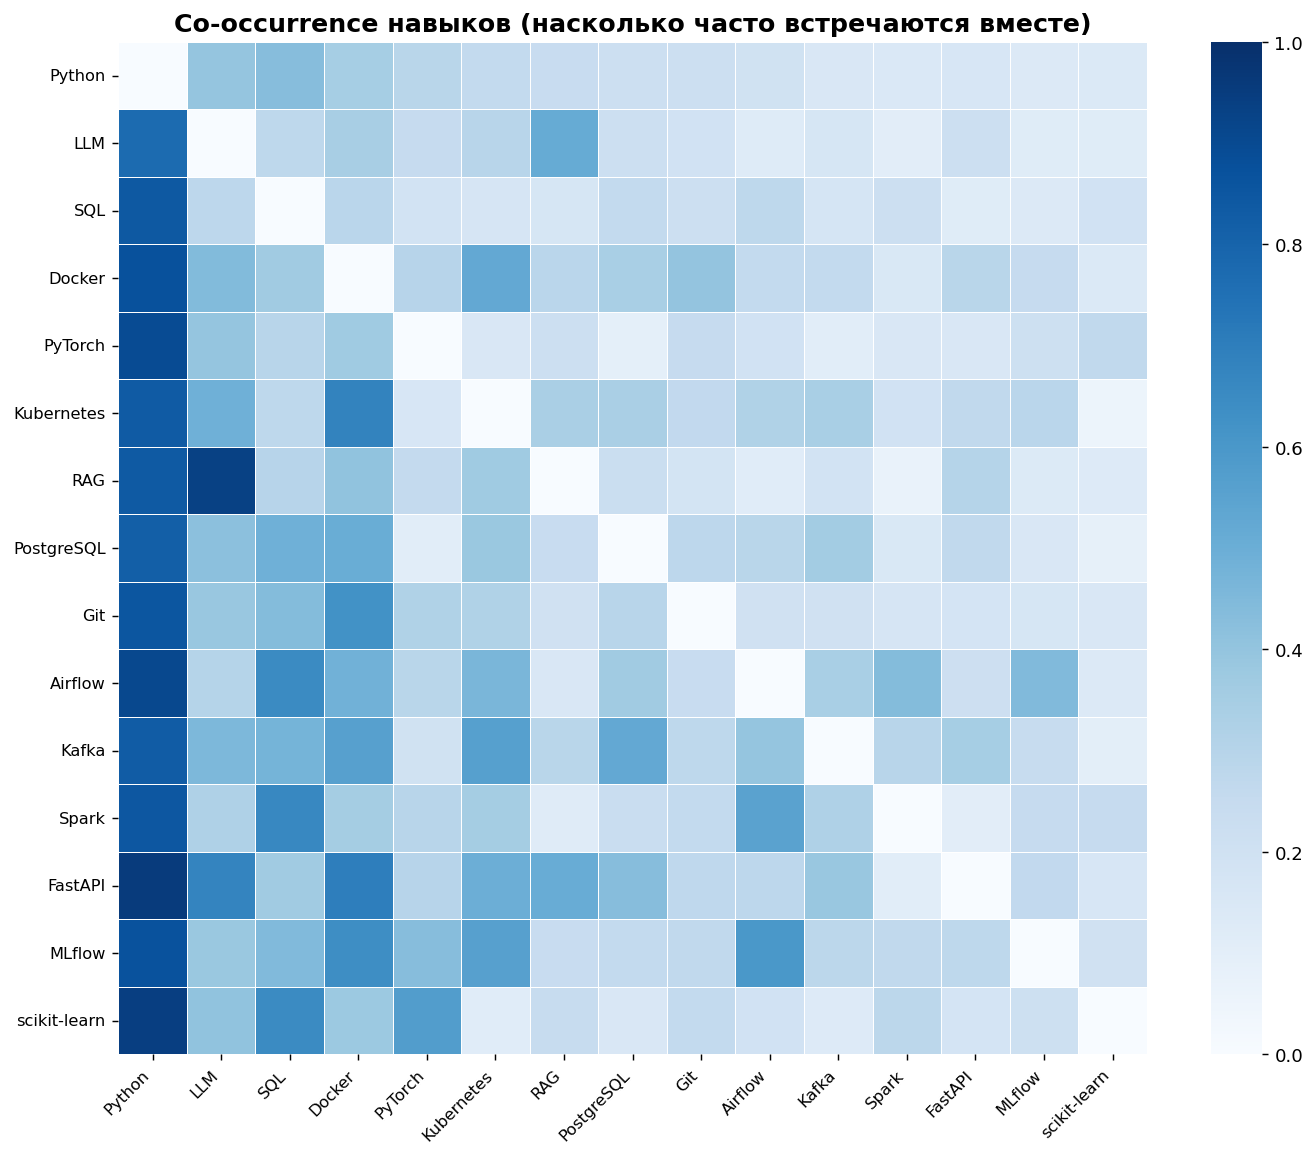

In [10]:
top15 = [s for s, _ in Counter(all_skills).most_common(15)]
comat = pd.DataFrame(0, index=top15, columns=top15)

for skill_list in df["skills"]:
    present = [s for s in skill_list if s in top15]
    for i, a in enumerate(present):
        for b in present[i+1:]:
            comat.loc[a, b] += 1
            comat.loc[b, a] += 1

# Нормализуем по диагонали
diag = pd.Series({s: Counter(all_skills)[s] for s in top15})
comat_norm = comat.div(diag, axis=0)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(comat_norm, annot=False, cmap="Blues",
            linewidths=0.3, ax=ax, vmin=0, vmax=1)
ax.set_title("Co-occurrence навыков (насколько часто встречаются вместе)",
             fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Сводная таблица по грейдам

In [11]:
rows = []
for level in ["junior", "middle", "senior"]:
    sub = df[df["level"] == level]
    sal_sub = sub[sub["salary_mid"].notna() & (sub["salary_mid"] > 20_000)]
    flat = [s for skills in sub["skills"] for s in skills]
    top3 = ", ".join([s for s, _ in Counter(flat).most_common(3)])
    top_city = sub["city"].value_counts().index[0] if len(sub) > 0 else "—"
    top_cat = sub["category_label"].value_counts().index[0] if len(sub) > 0 else "—"
    rows.append({
        "Грейд":         level.capitalize(),
        "Вакансий":      len(sub),
        "Топ специализация": top_cat,
        "Топ-3 навыка":  top3,
        "Топ город":     top_city,
        "Медиана з/п":   f"{sal_sub['salary_mid'].median()/1000:.0f}к" if len(sal_sub) >= 3 else "мало данных",
    })

pd.DataFrame(rows).set_index("Грейд")

,Вакансий,Топ специализация,Топ-3 навыка,Топ город,Медиана з/п
Грейд,,,,,
Junior,499,Data Science,"Python, SQL, LLM",Москва,100к
Middle,563,Data Science,"Python, SQL, LLM",Москва,100к
Senior,473,LLM / GenAI,"Python, LLM, SQL",Москва,100к
